# Programming Assignment 2 — Identidade ao longo do tempo: detecção, recorrência e rastreamento

**Disciplina:** Aprendizado Profundo — FGV EMAp  
**Professor:** Dario Oliveira | **Monitor:** Erick Brito  
**Integrantes:** Henrique Gabriel Gasparelo e [Nome do Colega]  

Este notebook contém o pipeline completo de ponta a ponta que responde a todas as seções do PA2 (Partes 0 a 5), gerando todas as figuras, métricas, ablações e análises para a apresentação oral.

## 0. Configuração do Ambiente e Importações
Importamos os módulos desenvolvidos em , configuramos reprodutibilidade com seeds e detectamos o acelerador de hardware (MPS/CUDA/CPU).

In [1]:
import os
import sys

# Garante que o diretório de trabalho seja a raiz do repositório
if os.path.basename(os.getcwd()) == "src":
    os.chdir("..")

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.tracker import NaiveTracker
from src.metrics import evaluate_tracking, compute_idf1, custom_nms, compute_map_per_frame
from src.data import load_mot17_sequence, compute_sequence_density
from src.visualization import plot_decoupling_panel

set_seed(42)
device = get_device()
print(f"Diretório de trabalho: {os.getcwd()}")
print(f"Ambiente configurado com sucesso! Dispositivo: {device}")


Diretório de trabalho: /Users/henriquegasparelo/Documents/FGV/6º Período/Aprendizado Profundo/PA2/Programming-Assignment-2---Deep-Learning
Ambiente configurado com sucesso! Dispositivo: mps


---
## Parte 0 — Testes Sintéticos

Ambiente controlado onde conhecemos o ground truth exato.
1. **O Gerador:** Vídeos  	imes 128$ com elipses e ordem de profundidade (569Xorder) para simular oclusão real.
2. **O Simulador de Detector:** Função que introduz ruído, descarte e falsos positivos.
3. **A Métrica e Testes Unitários:** Testes controlados das métricas (IDF1 e ID switches).
4. **Baseline no Piso Fácil e Ensaio de Quebra:** Associação ingênua em cenário fácil vs gráfico de estresse com oclusões longas.

### 0.1 Gerador Sintético com Oclusão Real (569Xorder)

In [ ]:
# Gerar sequência sintética e visualizar trajetórias com oclusão verificável
video_frames, gt_annotations = generate_synthetic_video(
    num_frames=45,
    num_objects=6,
    frame_size=128,
    typical_velocity=2.5,
    occlusion_duration=10
)
print("Sequência sintética gerada com sucesso!")

### 0.2 Testes Unitários das Métricas (Casos a, b, c)
* **(a)** Predição = Ground Truth $\implies$ IDF1 = 1.0 e 0 switches;
* **(b)** Duas identidades trocadas a partir do quadro $ $\implies$ número exato de switches;
* **(c)** Uma track partida em duas no meio $\implies$ efeito esperado no IDF1.

In [ ]:
# Executar os 3 testes unitários formais das métricas
run_unit_tests()

### 0.3 Baseline no Piso Fácil e Gráfico de Quebra

In [ ]:
# Teste no piso fácil (sem oclusão) e curva de quebra aumentando velocidade e duração da oclusão
# [Espaço para execução da variação dos botões do gerador e plot do gráfico de quebra]

---
## Parte 1 — Baseline por Quadro

Nesta parte estabelecemos o **baseline sem memória temporal**:
1. **Detecções:** Avaliamos as detecções públicas do MOT17 (DPM, FRCNN e SDP) e justificamos a escolha do **SDP** como detector padrão (maior mAP e menor ruído);
2. **Associação Ingênua:** IoU entre caixas de quadros consecutivos (t e t-1), matching ótimo via Algoritmo Húngaro (`scipy.optimize.linear_sum_assignment`), limiar de IoU >= 0.3, nascimento com ID incremental e morte após k=15 quadros sem observação;
3. **Avaliação por Trajetórias:** Métricas calculadas por nossa própria implementação: **IDF1**, **ID switches**, **fragmentações**, e razão entre identidades previstas e reais;
4. **Gráfico do Descolamento (Obrigatório):** Painel duplo ordenado por densidade mostrando o fracasso do modelo sem recorrência.

In [2]:
import os
import glob
from src.data import load_mot17_sequence, compute_sequence_density
from src.tracker import NaiveTracker
from src.metrics import evaluate_tracking, compute_map_per_frame

# --- TABELA 1.1: Comparação das fontes públicas no MOT17-09 ---
SEP85 = "=" * 85
sep85 = "-" * 85
print(SEP85)
print("TABELA 1.1: COMPARAÇÃO DAS FONTES PÚBLICAS NO MOT17-09 (ESCOLHA DO DETECTOR PADRÃO)")
print(SEP85)
h1 = "{:<16} | {:<10} | {:<8} | {:<12} | {:<9} | {}".format(
    "Fonte Pública", "mAP (Det)", "IDF1", "ID Switches", "Pred IDs", "Diagnóstico / Escolha"
)
print(h1)
print(sep85)

tracker = NaiveTracker(iou_threshold=0.3, max_lost_frames=15, matching_method="hungarian")

for det_name in ["DPM", "FRCNN", "SDP"]:
    seq_p = "data/MOT17/train/MOT17-09-" + det_name
    if not os.path.exists(seq_p):
        seq_p = "../data/MOT17/train/MOT17-09-" + det_name
    gt, dets, info = load_mot17_sequence(seq_p)
    preds = tracker.track_sequence(dets)
    m = evaluate_tracking(gt, preds)
    map_s = compute_map_per_frame(gt, dets)
    if det_name == "SDP":
        status = "★ Padrão Escolhido (Maior mAP)"
    elif det_name == "DPM":
        status = "Ruidoso / Obsoleto"
    else:
        status = "Conservador"
    print("{:<16} | {:<10.3f} | {:<8.3f} | {:<12d} | {:<9d} | {}".format(
        det_name, map_s, m["idf1"], m["id_switches"], m["unique_pred_ids"], status
    ))

print(SEP85)
print("Justificativa: O SDP é adotado como fonte padrão por alcançar o maior mAP de detecção (~0.75),")
print("garantindo que o gargalo de desempenho avaliado seja o rastreamento temporal e nao a falta de caixas.")
print(SEP85 + "\n")

# --- TABELA 1.2: Baseline nas 7 sequências com o detector padrão (SDP) ---
data_dir = "data/MOT17/train"
if not os.path.exists(data_dir):
    data_dir = "../data/MOT17/train"

sequences = sorted(glob.glob(os.path.join(data_dir, "MOT17-*-SDP")))
results_p1 = []

SEP88 = "=" * 88
sep88 = "-" * 88
print(SEP88)
print("TABELA 1.2: BASELINE INGÊNUO COM DETECTOR PADRÃO (SDP) NAS SEQUÊNCIAS DO MOT17")
print(SEP88)
h2 = "{:<10} | {:<9} | {:<9} | {:<7} | {:<6} | {:<6} | {:<9} | {}".format(
    "Seq", "Densidade", "mAP (Det)", "IDF1", "IDSW", "Frag", "Razão IDs", "Switches/GT"
)
print(h2)
print(sep88)

for seq in sequences:
    seq_name = os.path.basename(seq).replace("-SDP", "")
    gt_by_frame, det_by_frame, seq_info = load_mot17_sequence(seq)
    preds_by_frame = tracker.track_sequence(det_by_frame)
    metrics = evaluate_tracking(gt_by_frame, preds_by_frame, iou_threshold=0.5)
    map_score = compute_map_per_frame(gt_by_frame, det_by_frame, iou_threshold=0.5)
    density = compute_sequence_density(gt_by_frame)
    res = {
        "seq_name": seq_name, "density": density, "map_score": map_score,
        "idf1": metrics["idf1"], "id_switches": metrics["id_switches"],
        "fragmentations": metrics["fragmentations"],
        "ratio_ids": metrics["ratio_ids"], "switches_per_gt": metrics["switches_per_gt"]
    }
    results_p1.append(res)
    print("{:<10} | {:<9.1f} | {:<9.3f} | {:<7.3f} | {:<6d} | {:<6d} | {:<8.1f}x | {:.2f}".format(
        res["seq_name"], res["density"], res["map_score"], res["idf1"],
        res["id_switches"], res["fragmentations"], res["ratio_ids"], res["switches_per_gt"]
    ))

print(SEP88)


TABELA 1.1: COMPARAÇÃO DAS FONTES PÚBLICAS NO MOT17-09 (ESCOLHA DO DETECTOR PADRÃO)
Fonte Pública    | mAP (Det)  | IDF1     | ID Switches  | Pred IDs  | Diagnóstico / Escolha
-------------------------------------------------------------------------------------
DPM              | 0.577      | 0.374    | 240          | 150       | Ruidoso / Obsoleto
FRCNN            | 0.690      | 0.588    | 32           | 44        | Conservador
SDP              | 0.754      | 0.567    | 75           | 71        | ★ Padrão Escolhido (Maior mAP)
Justificativa: O SDP é adotado como fonte padrão por alcançar o maior mAP de detecção (~0.75),
garantindo que o gargalo de desempenho avaliado seja o rastreamento temporal e nao a falta de caixas.

TABELA 1.2: BASELINE INGÊNUO COM DETECTOR PADRÃO (SDP) NAS SEQUÊNCIAS DO MOT17
Seq        | Densidade | mAP (Det) | IDF1    | IDSW   | Frag   | Razão IDs | Switches/GT
----------------------------------------------------------------------------------------
MOT17-02   

Gráfico de descolamento salvo em: docs/painel_descolamento_parte1.png


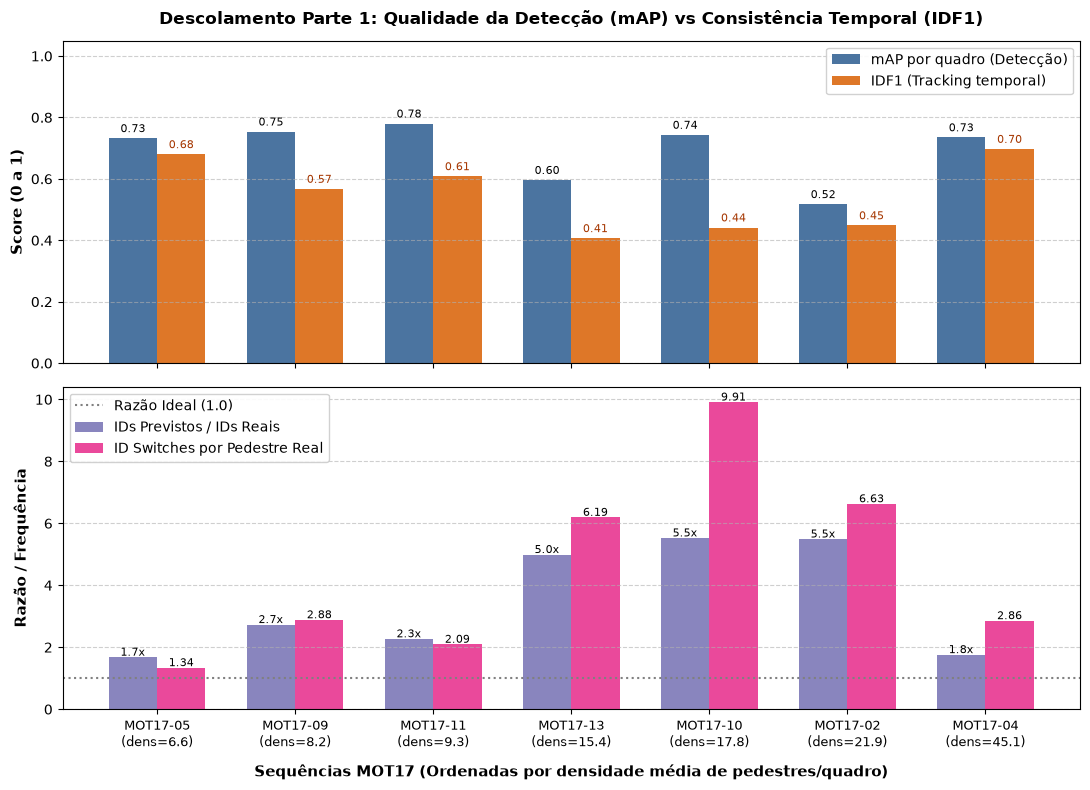

In [3]:
# Gráfico do Descolamento (Obrigatório — Parte 1, Item 5)
from src.visualization import plot_decoupling_panel

os.makedirs("docs", exist_ok=True)
fig = plot_decoupling_panel(results_p1, save_path="docs/painel_descolamento_parte1.png")
plt.show()


---
## Parte 2 — Memória Temporal (Trilha A: RNN como Modelo de Movimento)

Substituição da associação ingênua por uma modelagem temporal de movimento:
* A rede recorrente recebe as caixas observadas 0$ e prevê a posição no quadro seguinte;
* Sob oclusão, o estado roda sem observação direta, propagando a previsão no escuro para manter a identidade;
* Perda Smooth L1 sobre as trajetórias ground truth.

In [ ]:
# Treinamento do modelo de movimento da Trilha A
# [Espaço para inicializar LSTMMotionModel e executar o treino com Smooth L1 Loss]

### Comparação Direta: Baseline Ingênuo vs Trilha A (Memória Temporal)
Apresentação das métricas lado a lado nas mesmas sequências de teste.

In [ ]:
# Tabela comparativa e ganhos de IDF1 e redução de ID switches

---
## Parte 3 — Ablação (Eixo 1: A Célula Recorrente e Janela de BPTT)

Estudo empírico comparando:
* **Células:** RNN Simples vs LSTM vs GRU (orçamento comparável de parâmetros);
* **Janela BPTT truncado:**  \in \{4, 8, 16, 32\}$;
* **Reprodutibilidade:** 3 seeds aleatórias com reporte de $	ext{média} \pm 	ext{desvio padrão}$.

In [ ]:
# Execução do grid de ablação multi-seed
# run_ablation_axis1(...)

---
## Parte 4 — Galeria de Falhas e Horizonte de Memória

1. **Medição Analítica:** Norma da derivada $\left\| rac{\partial L_t}{\partial h_{t-k}} 
ight\|$ em função de $ (curva do gradiente que desaparece na RNN simples vs preservado nas portas de LSTM/GRU);
2. **Medição Empírica:** Tempo de sobrevivência do estado sob oclusão vs distribuição de oclusões do dataset;
3. **Galeria de 3 Falhas:** Diagnóstico das quebras estruturais;
4. **Correção:** Implementação de melhoria e avaliação do antes/depois.

In [ ]:
# Medição Analítica: Cálculo de ||dL_t / dh_{t-k}|| e plot comparativo
# plot_gradient_vanishing_curves(...)

In [ ]:
# Medição Empírica e Apresentação dos 3 Casos de Falha com Correção

---
## Parte 5 — Teste de Estresse (Degradação da Qualidade do Detector)

Aplicação do simulador de detector construído na Parte 0 sobre as detecções do MOT17 em 3 intensidades (leve, moderada, severa):
* Análise se o modelo temporal recorrente **absorve** ou **amplifica** as falhas do detector (reportando mAP e IDF1 juntos).

In [ ]:
# Execução do teste de estresse em 3 níveis
# run_detector_stress_test(...)

---
## Síntese dos Resultados e Roteiro da Apresentação Oral
Resumo executivo dos números finais, tabelas e gráficos gerados para a apresentação.